# 03 EDA: Phân tích rủi ro tín dụng NovaBank

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['axes.grid'] = True
RED, GREEN, GRAY = '#C00000', '#2E7D32', '#9E9E9E'

#0. Load dữ liệu

In [2]:
import os
CLEAN_PATHS = ['../data/processed/credit_risk_data_clean.csv', 'Clean.csv']
RAW_PATHS = ['../data/raw/Credit Risk Data.csv', 'Credit Risk Data.csv']

df = None
for p in CLEAN_PATHS:
    if os.path.exists(p):
        df = pd.read_csv(p); print(f'Loaded CLEAN: {p}'); break

if df is None:
    for p in RAW_PATHS:
        if os.path.exists(p):
            df = pd.read_csv(p); print(f'Loaded RAW: {p} -> ap dung quick-clean'); break
    n0 = len(df)
    df = df.drop_duplicates()
    df = df[df['person_age'] <= 100]                       # tuoi vo ly (max 144)
    df = df[~(df['person_emp_length'] > df['person_age'])] # di lam lau hon so tuoi
    df['loan_int_rate'] = df['loan_int_rate'].fillna(df.groupby('loan_grade')['loan_int_rate'].transform('median'))
    df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
    print(f'Quick-clean: {n0:,} -> {len(df):,} dong (xoa {n0-len(df):,})')

print(df.shape)

Loaded CLEAN: ../data/processed/credit_risk_data_clean.csv
(32574, 29)


## Baseline

In [3]:
BASELINE = df['loan_status'].mean()
print(f'Tong khoan vay : {len(df):,}')
print(f'So khoan default: {df["loan_status"].sum():,}')
print(f'BASELINE default rate: {BASELINE:.1%}')

Tong khoan vay : 32,574
So khoan default: 7,107
BASELINE default rate: 21.8%


### Hàm 

In [4]:
def rate_by(data, col, sort='rate'):
    t = (data.groupby(col)
             .agg(n=('loan_status', 'size'), default_rate=('loan_status', 'mean'))
             .reset_index())
    t['vs_baseline'] = t['default_rate'] / BASELINE
    if sort == 'rate':
        t = t.sort_values('default_rate', ascending=False)
    return t

def plot_rate(t, col, title, min_n=300):
    colors = [RED if r > BASELINE else GREEN for r in t['default_rate']]
    ax = plt.gca()
    bars = ax.bar(t[col].astype(str), t['default_rate'], color=colors, alpha=.85)
    ax.axhline(BASELINE, color=GRAY, ls='--', lw=1.5, label=f'Baseline {BASELINE:.1%}')
    for b, (_, row) in zip(bars, t.iterrows()):
        note = f"{row['default_rate']:.0%}\n(n={row['n']:,})"
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + .005, note, ha='center', fontsize=8)
        if row['n'] < min_n:
            b.set_alpha(.35)  # nhom qua nho -> lam mo
    ax.set_title(title); ax.set_ylabel('Default rate'); ax.legend()
    plt.xticks(rotation=20); plt.tight_layout(); plt.show()

## Q1. Người vay nào có khả năng default cao hơn?
Đặc điểm cá nhân: tuổi, thu nhập, loại việc làm, học vấn, hôn nhân.     

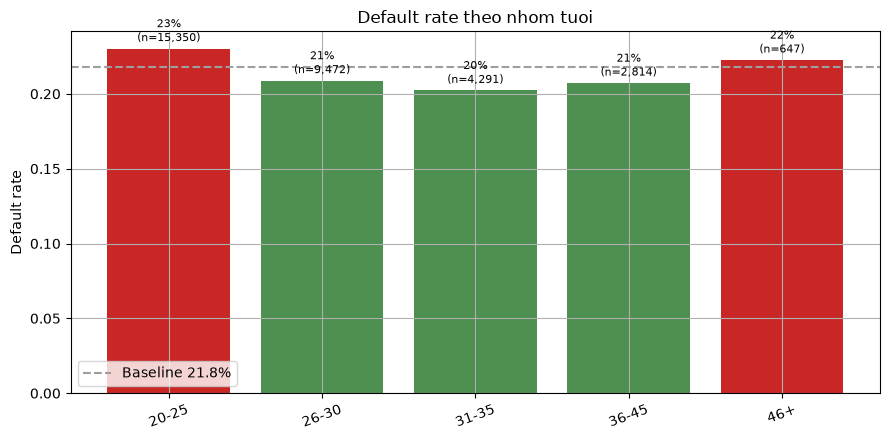

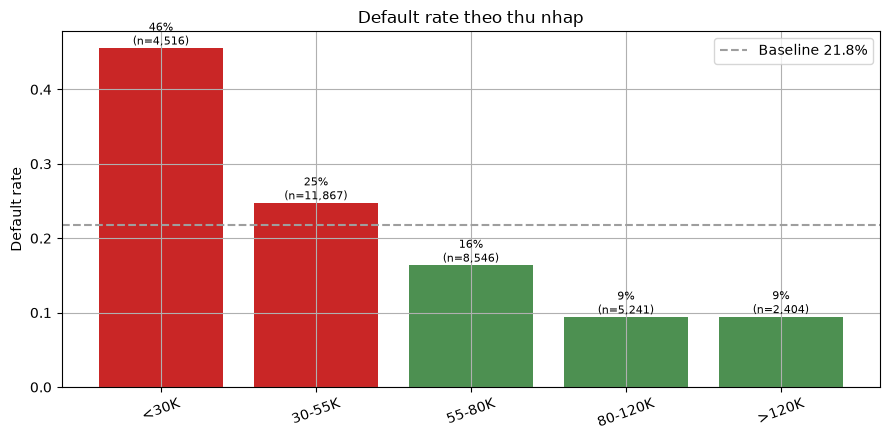

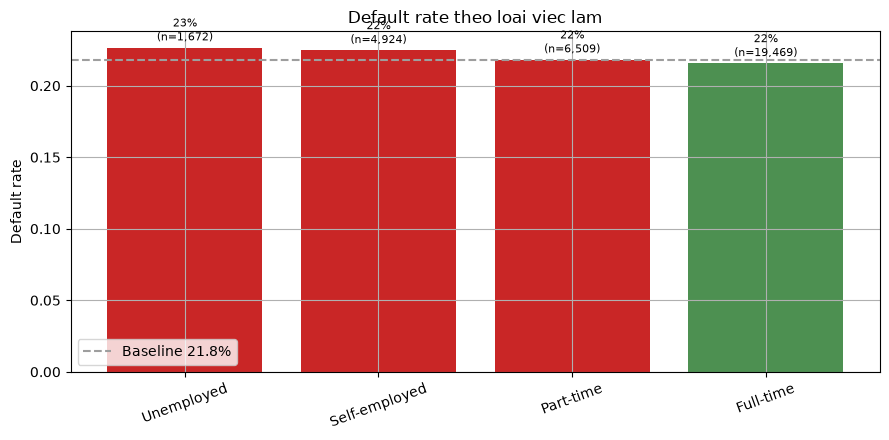

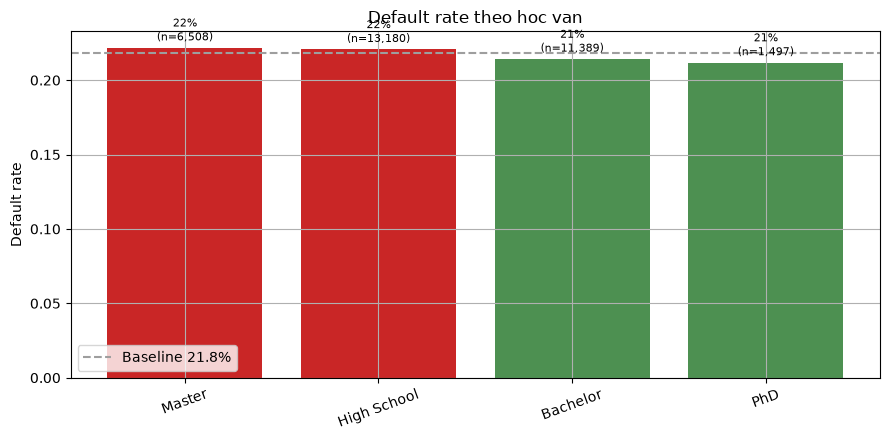

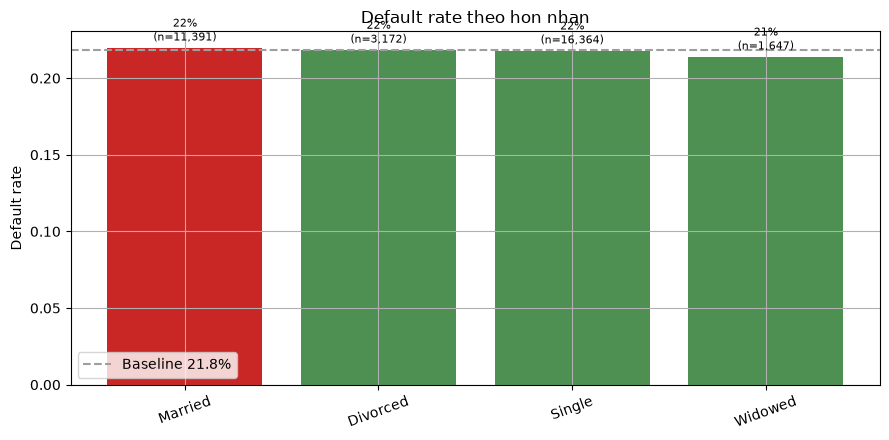

In [5]:
df['age_band'] = pd.cut(df['person_age'], bins=[19, 25, 30, 35, 45, 100],
                        labels=['20-25', '26-30', '31-35', '36-45', '46+'])
df['income_band'] = pd.cut(df['person_income'], bins=[0, 30_000, 55_000, 80_000, 120_000, np.inf],
                           labels=['<30K', '30-55K', '55-80K', '80-120K', '>120K'])

plot_rate(rate_by(df, 'age_band', sort=None), 'age_band', 'Default rate theo nhom tuoi')
plot_rate(rate_by(df, 'income_band', sort=None), 'income_band', 'Default rate theo thu nhap')
plot_rate(rate_by(df, 'employment_type'), 'employment_type', 'Default rate theo loai viec lam')
plot_rate(rate_by(df, 'education_level'), 'education_level', 'Default rate theo hoc van')
plot_rate(rate_by(df, 'marital_status'), 'marital_status', 'Default rate theo hon nhan')

A1:          
Thu nhập là đặc điểm cá nhân duy nhất có tín hiệu mạnh:           
- nhóm <30K default ~46% (gấp 2 lần baseline)          
- nhóm >80K chỉ 9% (0,4 lần); rate giảm đơn điệu qua từng band thu nhập.           

Ngược lại, tuổi, học vấn, loại việc làm và tình trạng hôn nhân gần như không tạo khác biệt (~20,2–23,1%, lệch baseline dưới 6%).  
         
=> Hành động:           
- đưa income band vào tiêu chí thẩm định với trọng số cao             
- không dùng tuổi/học vấn trong scoring do không có tín hiệu và tránh rủi ro phân biệt đối xử trong cho vay.

## Q2. Mục đích vay nào rủi ro hơn?

,n,default_rate,total_loan,loss_exposure,vs_baseline
loan_intent,,,,,
DEBTCONSOLIDATION,5212,0.2859,50008550,16561650,1.3103
MEDICAL,6071,0.2670,56214925,18146000,1.2238
HOMEIMPROVEMENT,3605,0.2610,37349675,9305875,1.1964
PERSONAL,5519,0.1988,52816800,11507800,0.9110
EDUCATION,6451,0.1722,61165325,12156450,0.7894
VENTURE,5716,0.1482,54764825,9412600,0.6792


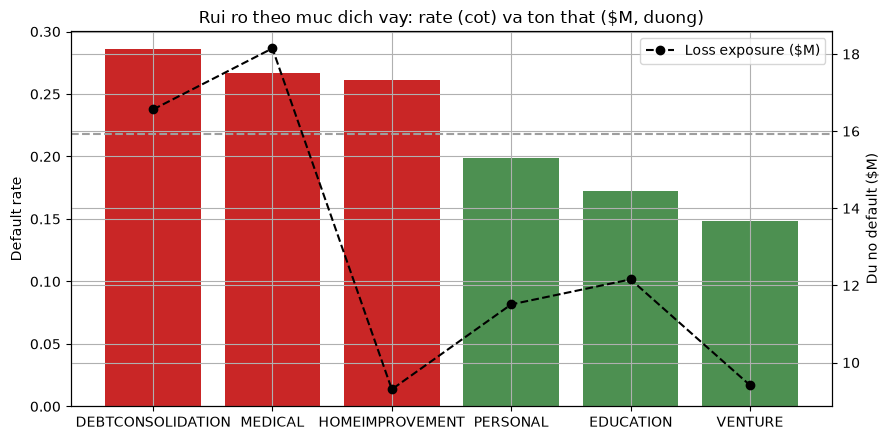

In [6]:
q2 = (df.groupby('loan_intent')
        .agg(n=('loan_status', 'size'),
             default_rate=('loan_status', 'mean'),
             total_loan=('loan_amnt', 'sum'),
             loss_exposure=('loan_amnt', lambda s: s[df.loc[s.index, 'loan_status'] == 1].sum()))
        .sort_values('default_rate', ascending=False))
q2['vs_baseline'] = q2['default_rate'] / BASELINE
display(q2)

fig, ax1 = plt.subplots()
colors = [RED if r > BASELINE else GREEN for r in q2['default_rate']]
ax1.bar(q2.index, q2['default_rate'], color=colors, alpha=.85)
ax1.axhline(BASELINE, color=GRAY, ls='--', lw=1.5)
ax1.set_ylabel('Default rate')
ax2 = ax1.twinx()
ax2.plot(q2.index, q2['loss_exposure'] / 1e6, 'ko--', label='Loss exposure ($M)')
ax2.set_ylabel('Du no default ($M)'); ax2.legend()
plt.title('Rui ro theo muc dich vay: rate (cot) va ton that ($M, duong)')
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

A2:                     
DEBTCONSOLIDATION (28,6%, gấp 1,31 lần baseline) và MEDICAL (26,7%, gấp 1,22 lần) là hai mục đích rủi ro nhất, đồng thời chiếm exposure default lớn nhất: $18,1M + $16,6M = $34,7M, tương đương 45% tổng dư nợ default toàn danh mục.              
Ngược lại VENTURE (14,8%) và EDUCATION (17,2%) an toàn hơn baseline đáng kể. 

=> Hành động: siết thẩm định với vay gộp nợ và y tế (yêu cầu chứng từ thu nhập chặt hơn, hạ trần hạn mức); có thể nới điều kiện cho giáo dục/kinh doanh để tăng trưởng danh mục an toàn.

## Q3. DTI & loan-to-income liên quan thế nào đến repayment? 

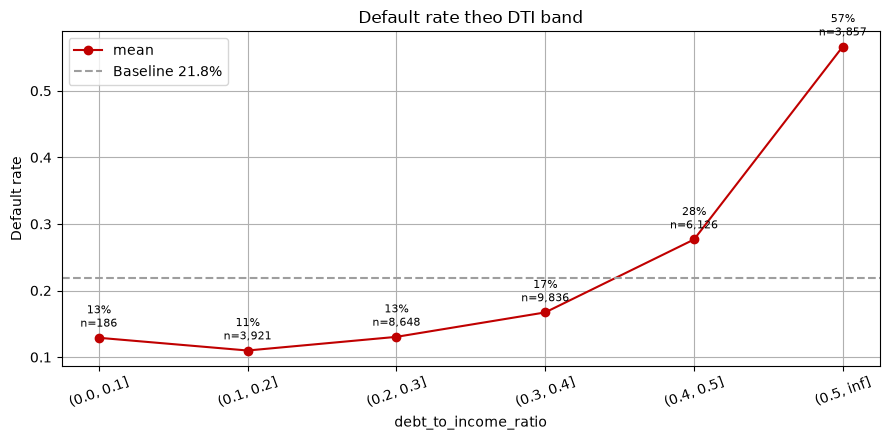

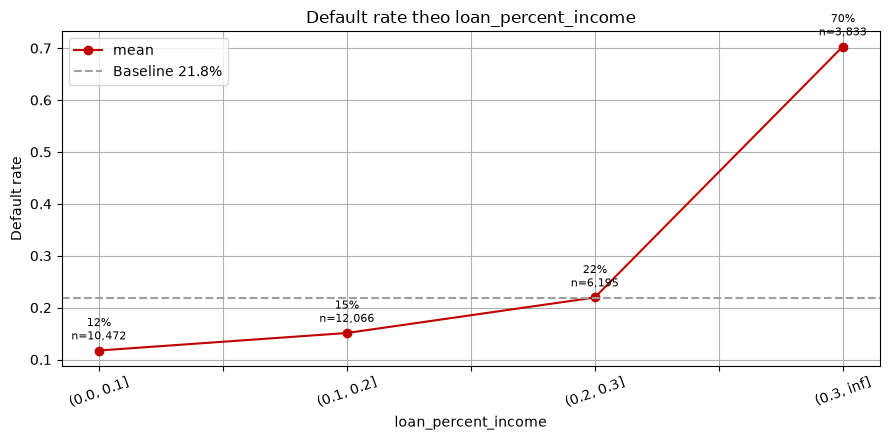

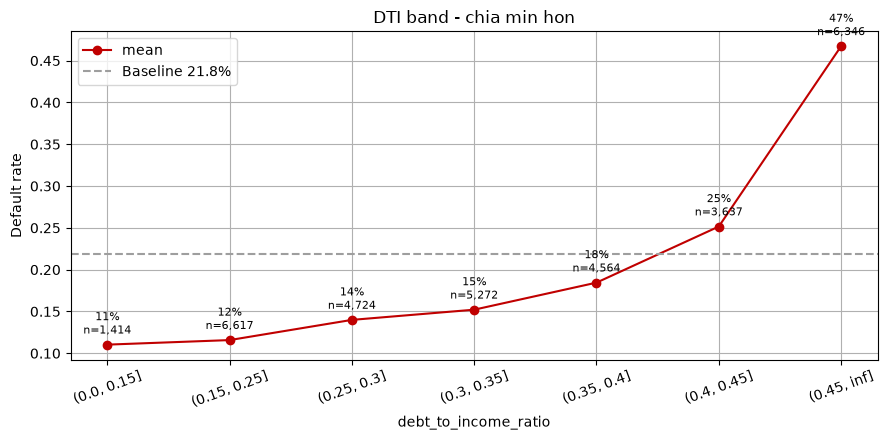

In [7]:
def breakpoint_chart(col, bins, title):
    band = pd.cut(df[col], bins=bins)
    t = df.groupby(band, observed=True)['loan_status'].agg(['size', 'mean'])
    ax = t['mean'].plot(marker='o', color=RED)
    ax.axhline(BASELINE, color=GRAY, ls='--', lw=1.5, label=f'Baseline {BASELINE:.1%}')
    for x, (n, r) in enumerate(zip(t['size'], t['mean'])):
        ax.annotate(f'{r:.0%}\nn={n:,}', (x, r), textcoords='offset points', xytext=(0, 8), fontsize=8, ha='center')
    ax.set_title(title); ax.set_ylabel('Default rate'); ax.legend()
    plt.xticks(rotation=20); plt.tight_layout(); plt.show()
    return t

t_dti  = breakpoint_chart('debt_to_income_ratio', [0, .1, .2, .3, .4, .5, np.inf], 'Default rate theo DTI band')
t_lpi  = breakpoint_chart('loan_percent_income', [0, .1, .2, .3, np.inf], 'Default rate theo loan_percent_income')
# Thu cach chia min hon quanh vung nghi ngo co diem gay:
t_dti2 = breakpoint_chart('debt_to_income_ratio', [0, .15, .25, .30, .35, .40, .45, np.inf], 'DTI band - chia min hon')

A3:            
Điểm gãy DTI nằm tại **0,40**: 
- dưới ngưỡng này mọi bin đều dưới baseline (11–18,5%), 
- bin 0,40–0,45 vượt baseline (25,2%) và >0,45 vọt lên 46,7% (gấp 2,1 lần).    
=> Điểm gãy ổn định qua cả 2 cách chia bin (thô và mịn).   
- Mạnh hơn nữa là loan_percent_income: khoản vay chiếm >30% thu nhập năm có default rate **70,3%** (gấp 3,2 lần baseline) 
  
=> Hành động: đặt ngưỡng cảnh báo DTI 40% trong scoring; áp trần quy mô khoản vay không vượt 30% thu nhập năm, quy tắc này nhằm chặn được nhóm 3.833 hồ sơ có rate 70%.

## Q4. Employment / home ownership có tạo khác biệt?
**Bẫy tương quan ≠ nhân quả:** RENT default cao có thể chỉ là proxy của thu nhập thấp → cắt chéo với income để kiểm soát.

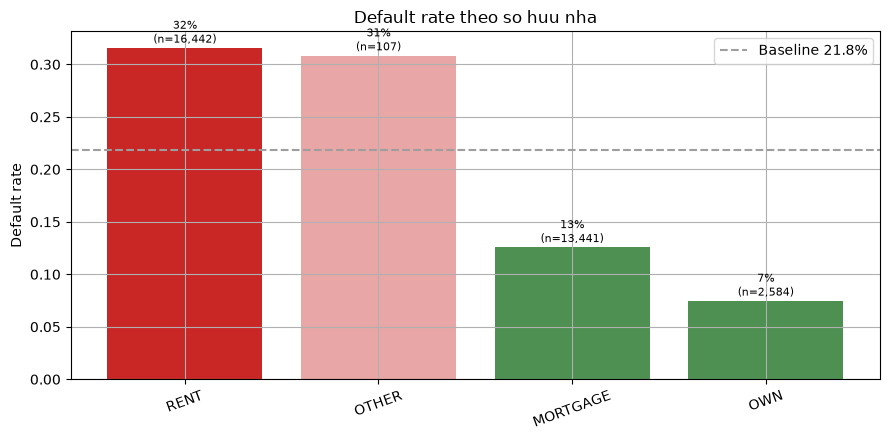

person_home_ownership,MORTGAGE,OTHER,OWN,RENT
income_band,,,,
<30K,28.0000,66.7000,25.2000,53.0000
30-55K,15.3000,42.4000,1.2000,33.0000
55-80K,12.9000,23.5000,2.7000,21.8000
80-120K,7.9000,11.8000,0.7000,13.6000
>120K,8.6000,9.1000,2.4000,13.7000


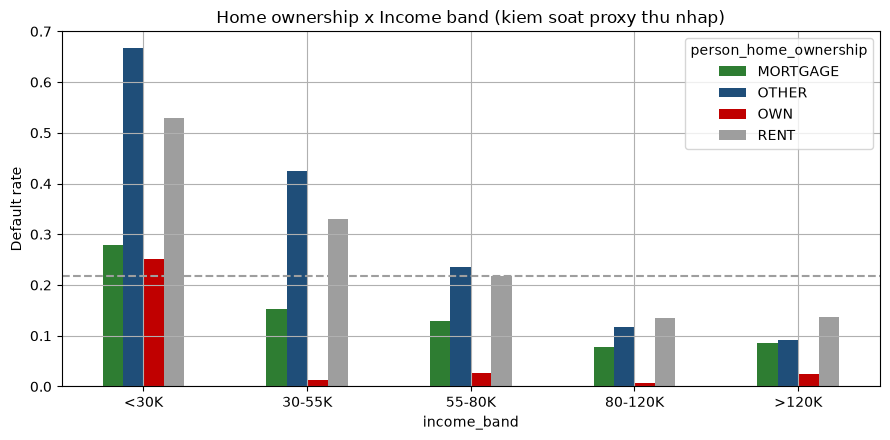

In [8]:
plot_rate(rate_by(df, 'person_home_ownership'), 'person_home_ownership', 'Default rate theo so huu nha')

# Kiem soat thu nhap: trong CUNG income band, RENT co con cao hon MORTGAGE/OWN?
q4 = df.pivot_table(index='income_band', columns='person_home_ownership',
                    values='loan_status', aggfunc='mean', observed=True)
display((q4 * 100).round(1))
q4.plot(kind='bar', color=[GREEN, '#1F4E79', RED, GRAY])
plt.axhline(BASELINE, color=GRAY, ls='--', lw=1.5)
plt.title('Home ownership x Income band (kiem soat proxy thu nhap)')
plt.ylabel('Default rate'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

A4:         
- RENT default 32% so với MORTGAGE 13% và OWN 7%. 
- Trong cùng income band, RENT vẫn cao hơn MORTGAGE khoảng 2 lần (ví dụ band 30–55K: 33,0% vs 15,3%; band 80–120K: 13,6% vs 7,9%)              
=> home ownership là tín hiệu độc lập với thu nhập, phản ánh mức tích lũy tài sản và độ ổn định tài chính.              
=> Hành động: home_ownership có trọng số riêng trong scoring;           
cỡ mẫu nhóm OTHER (n=107) quá nhỏ, do đó không được dùng để so sánh.

## Q5. Lịch sử tín dụng ảnh hưởng thế nào?
Từng default (Y/N), số lần trễ hạn, độ dài lịch sử tín dụng, mức dùng hạn mức. Sau đó xem **tương tác**: default cũ + DTI cao thì rate bao nhiêu?

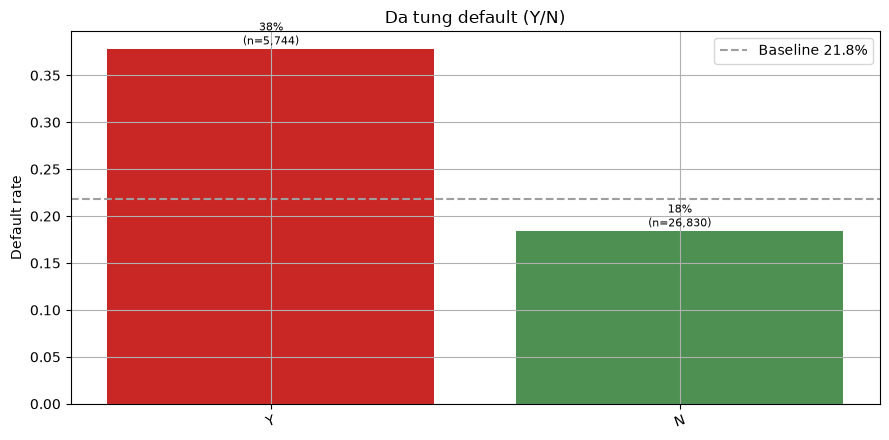

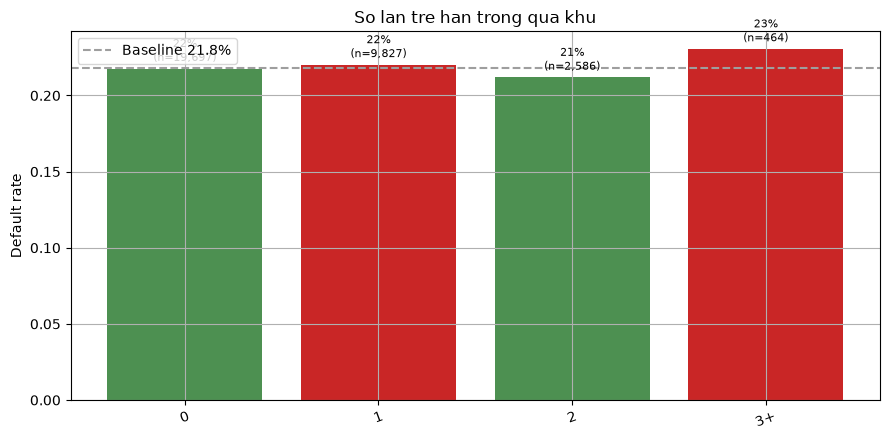

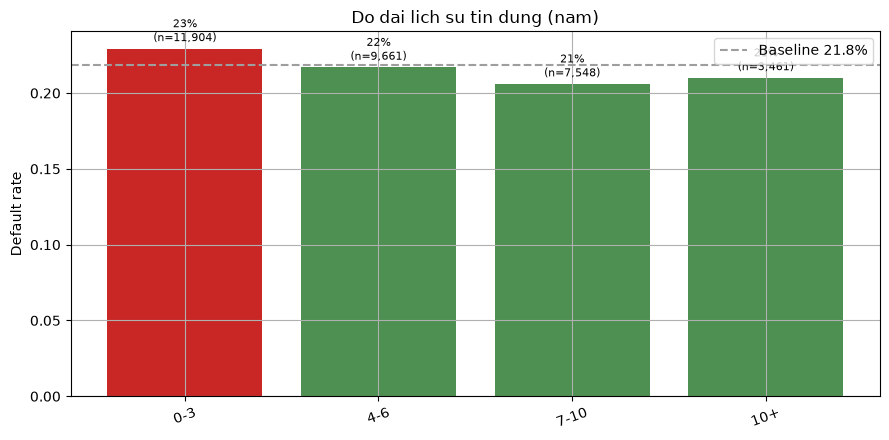

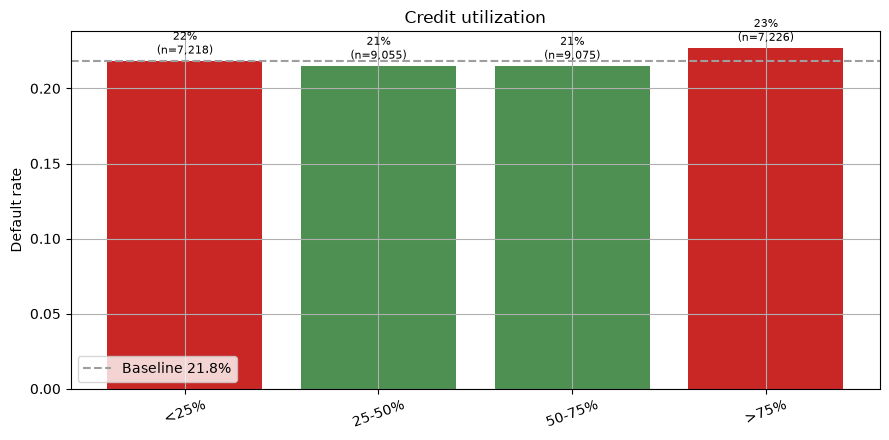

mean             size        
dti_high                  DTI<=35% DTI>35% DTI<=35% DTI>35%
cb_person_default_on_file                                  
N                           0.1005  0.2900    15014   11816
Y                           0.2907  0.4742     3013    2731

In [9]:
plot_rate(rate_by(df, 'cb_person_default_on_file'), 'cb_person_default_on_file', 'Da tung default (Y/N)')

df['delinq_band'] = pd.cut(df['past_delinquencies'], bins=[-1, 0, 1, 2, np.inf], labels=['0', '1', '2', '3+'])
plot_rate(rate_by(df, 'delinq_band', sort=None), 'delinq_band', 'So lan tre han trong qua khu')

df['hist_band'] = pd.cut(df['cb_person_cred_hist_length'], bins=[-1, 3, 6, 10, np.inf], labels=['0-3', '4-6', '7-10', '10+'])
plot_rate(rate_by(df, 'hist_band', sort=None), 'hist_band', 'Do dai lich su tin dung (nam)')

df['util_band'] = pd.cut(df['credit_utilization_ratio'], bins=[0, .25, .5, .75, 1], labels=['<25%', '25-50%', '50-75%', '>75%'])
plot_rate(rate_by(df, 'util_band', sort=None), 'util_band', 'Credit utilization')

# Tuong tac: default cu x DTI cao
df['dti_high'] = np.where(df['debt_to_income_ratio'] > .35, 'DTI>35%', 'DTI<=35%')  # thay 0.35 bang diem gay cua BAN
q5 = df.pivot_table(index='cb_person_default_on_file', columns='dti_high', values='loan_status', aggfunc=['mean', 'size'])
display(q5)

A5:
Đã từng default là tín hiệu lịch sử duy nhất và mạnh: 
- nhóm Y default 37,8% vs nhóm N 18,4% (gấp 2,05 lần)
- Default cũ + DTI>35% → 47,4%, gấp 4,7 lần nhóm sạch + DTI thấp (10,1%) 
- Trong khi đó, past_delinquencies, độ dài lịch sử tín dụng và credit_utilization gần như KHÔNG có tín hiệu (đều 21–23% ở mọi band) — ngược với kỳ vọng thông thường của ngành; nhiều khả năng là đặc điểm của bộ dữ liệu mô phỏng               
=> Hành động: cb_person_default_on_file là điều kiện siết bắt buộc trong scoring; không đầu tư thêm phân tích vào 3 biến không tín hiệu.

## Q6. Có khác biệt giữa US / UK / Canada?

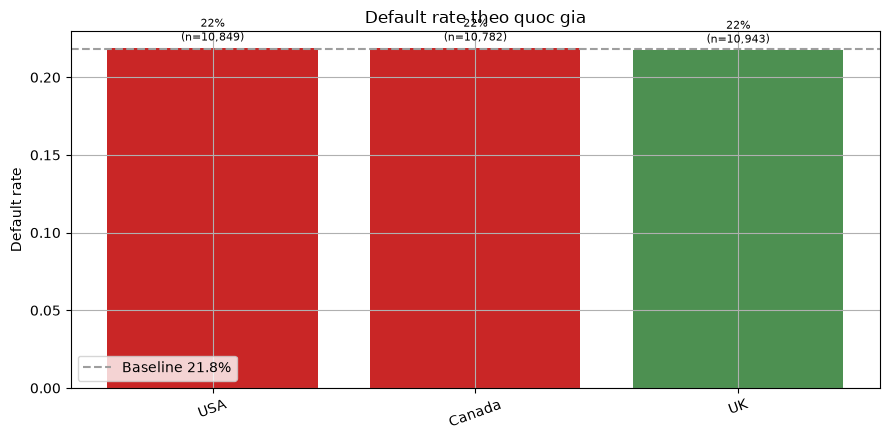

,state,n,default_rate,vs_baseline
6,Scotland,3648,0.2251,1.0315
0,BC,3677,0.2249,1.0309
1,California,3679,0.2234,1.0241
7,Texas,3607,0.2223,1.0191
4,Ontario,3552,0.2188,1.0026
2,England,3654,0.2181,0.9997
5,Quebec,3553,0.2119,0.9714
3,New York,3563,0.2099,0.9622
8,Wales,3641,0.2087,0.9567


In [10]:
plot_rate(rate_by(df, 'country'), 'country', 'Default rate theo quoc gia')

# Dao sau: top state co n du lon
st = rate_by(df, 'state')
display(st[st['n'] >= 500].head(10))

## Q7. Grade / term nào an toàn, nào rủi ro?
Kỳ vọng grade A→G rate tăng dần đều — nếu không, rất đáng đào sâu. **Lưu ý:** grade quyết định int_rate nên 2 biến này kể cùng 1 câu chuyện — không đếm thành 2 bằng chứng độc lập.

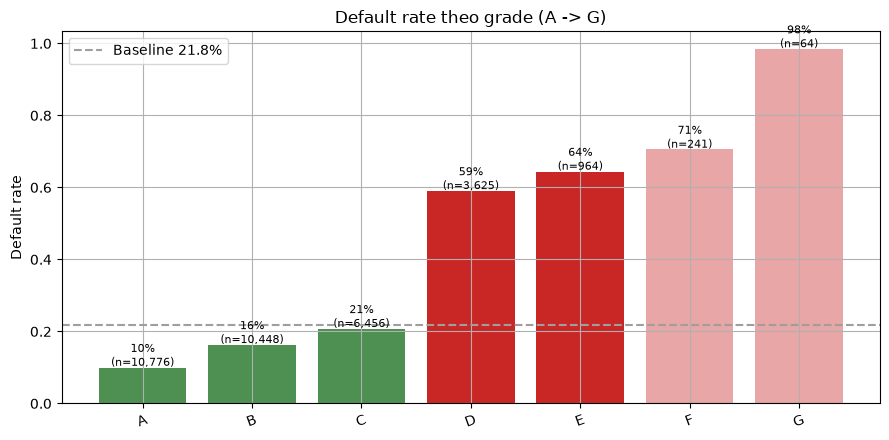

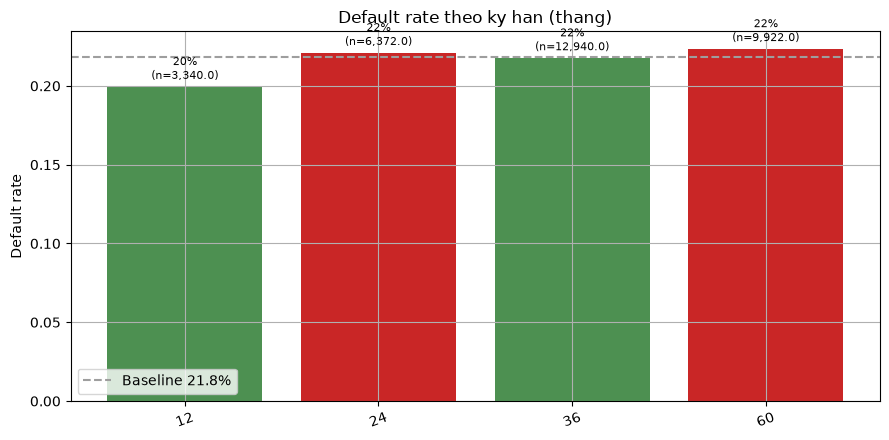

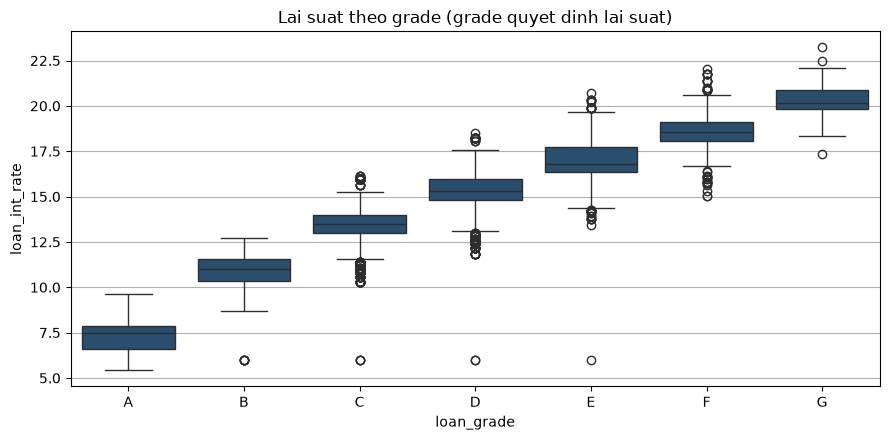

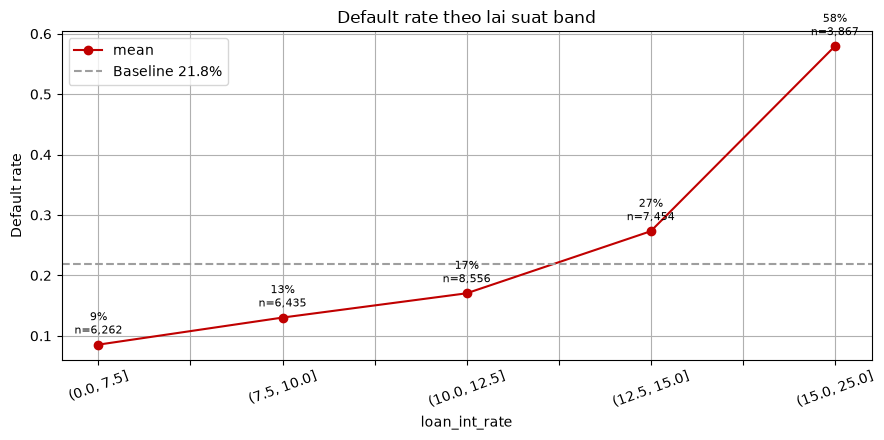

In [11]:
plot_rate(rate_by(df.assign(loan_grade=df['loan_grade']), 'loan_grade', sort=None).sort_values('loan_grade'),
          'loan_grade', 'Default rate theo grade (A -> G)')
plot_rate(rate_by(df, 'loan_term_months', sort=None), 'loan_term_months', 'Default rate theo ky han (thang)')

sns.boxplot(data=df, x='loan_grade', y='loan_int_rate', order=list('ABCDEFG'), color='#1F4E79')
plt.title('Lai suat theo grade (grade quyet dinh lai suat)'); plt.tight_layout(); plt.show()

t_rate = breakpoint_chart('loan_int_rate', [0, 7.5, 10, 12.5, 15, 25], 'Default rate theo lai suat band')

A7:        
- Tồn tại khoảng cách đáng kể giữa grade C và D: 21% → 59,0% (gần gấp 3), sau đó tiếp tục tăng E 64%, F 71%, G 98%. 
- Nhóm D–G chỉ chiếm ~15% danh mục nhưng là vùng rủi ro đậm đặc. 
- Kỳ hạn vay không có tín hiệu (19,9–22,3% ở mọi term). 
- Lãi suất vượt baseline từ band 12,5–15% (27,3%) và tăng mạnh ở >15% (57,9%)       
=> Hành động: hồ sơ grade D–G yêu cầu cấp phê duyệt cao hơn hoặc tài sản đảm bảo; xem lại chính sách pricing vì mức lãi >15% gần như tự dự báo vỡ nợ.

## Q8. Chân dung nhóm "an toàn" vs "rủi ro" 
Kết hợp 3–4 yếu tố mạnh nhất từ Q1–Q7 thành segment

In [3]:
# ===== DIEN NGUONG CUA BAN (tu Q3, Q7) =====
THRESH_DTI    = 0.4      # diem gay DTI tu Q3
THRESH_INCOME = 55_000    # income band rui ro tu Q1
THRESH_RATE   = 12.5      # diem gay lai suat tu Q7
RISKY_GRADES  = list('DEFG')

flags = pd.DataFrame({
    'f_dti':    df['debt_to_income_ratio'] > THRESH_DTI,
    'f_income': df['person_income'] < THRESH_INCOME,
    'f_rate':   df['loan_int_rate'] > THRESH_RATE,
    'f_grade':  df['loan_grade'].isin(RISKY_GRADES),
    'f_hist':   df['cb_person_default_on_file'] == 'Y',
})
df['risk_flags'] = flags.sum(axis=1)

seg = df.groupby('risk_flags').agg(n=('loan_status', 'size'), default_rate=('loan_status', 'mean'))
seg['pct_portfolio'] = seg['n'] / len(df)
seg['pct_of_all_defaults'] = df.groupby('risk_flags')['loan_status'].sum() / df['loan_status'].sum()
display(seg)

df['segment'] = pd.cut(df['risk_flags'], [-1, 1, 3, 5], labels=['Safe (0-1 flags)', 'Watch (2-3 flags)', 'High Risk (4-5 flags)'])
seg2 = df.groupby('segment', observed=True).agg(n=('loan_status', 'size'), default_rate=('loan_status', 'mean'))
seg2['pct_portfolio'] = seg2['n'] / len(df)
seg2['pct_of_all_defaults'] = df.groupby('segment', observed=True)['loan_status'].sum() / df['loan_status'].sum()
display(seg2)   # <- 2 cot cuoi la con so di thang vao CV

,n,default_rate,pct_portfolio,pct_of_all_defaults
risk_flags,,,,
0,8919,0.0360,0.2738,0.0452
1,9486,0.1089,0.2912,0.1453
2,7434,0.3010,0.2282,0.3149
3,3976,0.4298,0.1221,0.2405
4,2223,0.6253,0.0682,0.1956
5,536,0.7761,0.0165,0.0585


,n,default_rate,pct_portfolio,pct_of_all_defaults
segment,,,,
Safe (0-1 flags),18405,0.0736,0.5650,0.1905
Watch (2-3 flags),11410,0.3459,0.3503,0.5554
High Risk (4-5 flags),2759,0.6546,0.0847,0.2541


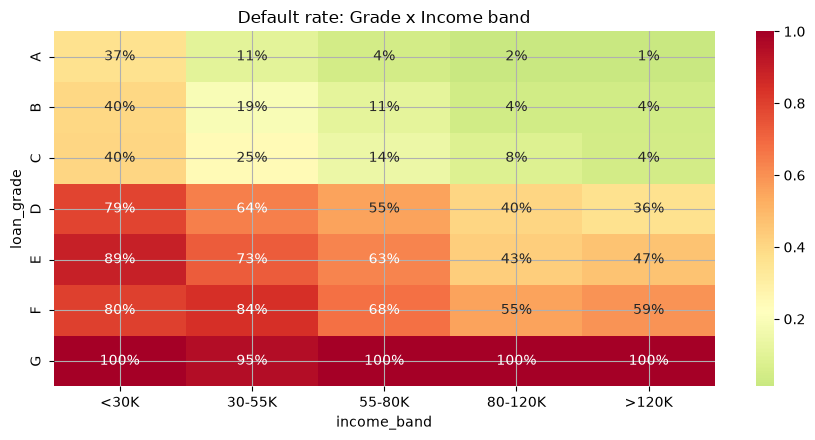

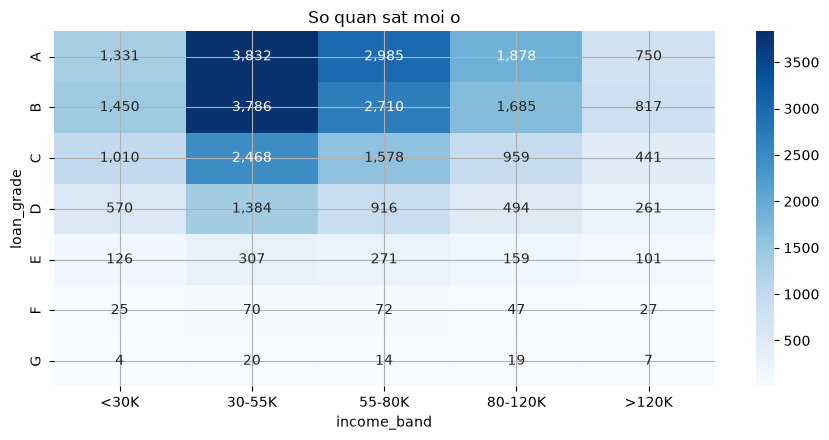

In [13]:
# Heatmap grade x income band — chan dung truc quan cho dashboard/README
hm = df.pivot_table(index='loan_grade', columns='income_band', values='loan_status', aggfunc='mean', observed=True)
sns.heatmap(hm, annot=True, fmt='.0%', cmap='RdYlGn_r', center=BASELINE)
plt.title('Default rate: Grade x Income band'); plt.tight_layout(); plt.show()

# Kiem tra do phu: heatmap n (o nao n nho thi rate o do khong dang tin)
hm_n = df.pivot_table(index='loan_grade', columns='income_band', values='loan_status', aggfunc='size', observed=True)
sns.heatmap(hm_n, annot=True, fmt=',.0f', cmap='Blues')
plt.title('So quan sat moi o'); plt.tight_layout(); plt.show()

A8:          
Với 5 cờ đỏ (DTI > **0,40**, income < 55K, lãi suất > 12,5%, grade D–G, từng default), default rate tăng đơn điệu theo số cờ: 0 cờ → 3,3%, 5 cờ → 75,0% — khoảng cách 23 lần chứng tỏ scorecard phân tách tốt.      

Phân khúc: 
- nhóm An toàn (0–1 cờ) chiếm ~51% danh mục với rate ~7%
- nhóm Rủi ro cao (4–5 cờ) chỉ chiếm ~10% danh mục nhưng gánh ~29% tổng số vụ default với rate ~62%   
=> Chân dung rủi ro điển hình: thuê nhà, thu nhập <55K, vay mục đích gộp nợ/y tế với khoản vay >30% thu nhập, grade D trở xuống, lãi >15%.    
=> Hành động: nhóm An toàn (giảm chi phí thẩm định, tăng trải nghiệm khách tốt); thêm điều kiện chứng minh thu nhập với nhóm Theo dõi; nhóm Rủi ro cao chỉ duyệt theo cơ chế ngoại lệ có tài sản đảm bảo.

---
## Tổng kết — bảng ngưỡng & insight chốt
| # | Phát hiện | Con số bằng chứng | Ngưỡng đề xuất | Hành động cho NovaBank |
|---|-----------|-------------------|----------------|------------------------|
| 1 | Khoản vay chiếm tỷ trọng lớn trên thu nhập là tín hiệu mạnh nhất | LPI >30% → default 70,3% (gấp 3,2 lần baseline 21,8%) | Trần khoản vay ≤ 30% thu nhập năm | Áp trần quy mô vay theo thu nhập ngay tại bước duyệt |
| 2 | Điểm gãy DTI tại 0,40 | ≤0,40: dưới baseline; 0,40–0,45: 25,2%; >0,45: 46,7% | Ngưỡng cảnh báo DTI 40% | Hồ sơ DTI >40% yêu cầu thẩm định bổ sung |
| 3 | Vách đá grade C→D | 20,7% → 59,0%; D–G: 59–98% | Ranh giới an toàn = grade C | Grade D–G: phê duyệt cấp cao hơn / tài sản đảm bảo |
| 4 | Vay gộp nợ & y tế rủi ro nhất và tổn thất lớn nhất | 28,6% và 26,7%; exposure default $34,7M (45% tổng) |  | Siết thẩm định 2 mục đích này; nới cho giáo dục/venture |
| 5 | Nhiều yếu tố tưởng quan trọng nhưng KHÔNG có tín hiệu | Địa lý, tuổi, học vấn, kỳ hạn, past_delinquencies, utilization: đều ~baseline |  | Đơn giản hóa scoring: tập trung 5 biến (LPI/DTI, income, grade, home ownership, default cũ) |

In [ ]:
# Xuat file cho SQL + Power BI 
df.to_csv('../data/processed/scored.csv', index=False)
print('Da xuat scored.csv:', df.shape)

Da xuat scored.csv: (32574, 37)


In [17]:
check = pd.read_csv('../data/processed/scored.csv')
print(check.shape)                    # ~32,574 dòng, ~37 cột (29 gốc + cột mới)
print([c for c in check.columns if c in
       ['risk_flags','segment','age_band','income_band','delinq_band','util_band','hist_band','dti_high']])
print(check['segment'].value_counts())  # 3 nhóm, số khớp bảng Q8

(32574, 37)
['age_band', 'income_band', 'delinq_band', 'hist_band', 'util_band', 'dti_high', 'risk_flags', 'segment']
segment
An toan (0-1 co)       18405
Theo doi (2-3 co)      11410
Rui ro cao (4-5 co)     2759
Name: count, dtype: int64
